In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate
)
from sklearn.tree import (
    DecisionTreeClassifier, plot_tree, export_text
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = os.path.abspath("..")

DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

CLUSTERED_CSV = os.path.join(DATA_DIR, "executions_clustered.csv")
CLF_DT_PKL = os.path.join(MODEL_DIR, "classifier.pkl")
CLF_RF_PKL = os.path.join(MODEL_DIR, "classifier_rf.pkl")
CLF_LR_PKL = os.path.join(MODEL_DIR, "classifier_lr.pkl")
CLF_LE_PKL = os.path.join(MODEL_DIR, "classifier_label_encoder.pkl")

<b>Feature Definition<b>

In [3]:
NUMERIC_FEATURES = [
    "severity_encoded",
    "impact_score",
    "score",
    "total_suggestions",
    "source_lines",
    "pattern_frequency",
    "line_proximity",
]
 
# one-hot prefix groups
PAT_PREFIX  = "pat_"
CPLX_PREFIX = "cplx_"
VAR_PREFIX  = "var_"
 
# classification target
TARGET_COL = "cluster_label"

<b>Load Data and Build Feature Matrix<b>

In [4]:
df = pd.read_csv(CLUSTERED_CSV)
print(f"Shape: {df.shape}\n")
print(f"Target distribution:\n{df[TARGET_COL].value_counts().to_string()}\n")

Shape: (1404, 36)

Target distribution:
cluster_label
cache_repeated_computation              432
cleanup_dead_unused_code                342
hoist_invariant                         288
reduce_nesting                          108
memoize_expensive_calls                 108
replace_string_concat                   108
cache_repeated_computation_satellite     18



In [5]:
# dynamically collect one-hot columns from CSV

pat_cols  = sorted([c for c in df.columns if c.startswith(PAT_PREFIX)])
cplx_cols = sorted([c for c in df.columns if c.startswith(CPLX_PREFIX)])
var_cols  = sorted([c for c in df.columns if c.startswith(VAR_PREFIX)])

In [6]:
ALL_FEATURES = pat_cols + cplx_cols + var_cols + NUMERIC_FEATURES

print(f"Total: {len(ALL_FEATURES)}")
print(f"Pattern one-hots: {len(pat_cols)} {pat_cols}\n")
print(f"Complexity one-hots: {len(cplx_cols)} {cplx_cols}\n")
print(f"Variant one-hots: {len(var_cols)} {var_cols}\n")
print(f"Numeric features: {len(NUMERIC_FEATURES)} {NUMERIC_FEATURES}\n")

Total: 26
Pattern one-hots: 10 ['pat_constant_folding', 'pat_dead_code', 'pat_early_return', 'pat_expensive_calls', 'pat_hot_loop', 'pat_loop_invariant', 'pat_nested_loops', 'pat_repeated_computation', 'pat_string_concat_loop', 'pat_unused_vars']

Complexity one-hots: 3 ['cplx_O(1)', 'cplx_O(n)', 'cplx_O(n²)']

Variant one-hots: 6 ['var_base', 'var_large_input', 'var_medium_input', 'var_small_input', 'var_with_branch_noise', 'var_with_setup_noise']

Numeric features: 7 ['severity_encoded', 'impact_score', 'score', 'total_suggestions', 'source_lines', 'pattern_frequency', 'line_proximity']



In [7]:
# cast bool columns to float and verify no nulls

X = df[ALL_FEATURES].astype(float)
assert X.isnull().sum().sum() == 0, "Nulls found in feature matrix"

<b>Encode Target<b>

In [8]:
le = LabelEncoder()
y  = le.fit_transform(df[TARGET_COL])
 
print("Encoded classes:")
for i, cls in enumerate(le.classes_):
    count = (y == i).sum()
    print(f"{i} -> '{cls}' ({count} rows)")
print()

Encoded classes:
0 -> 'cache_repeated_computation' (432 rows)
1 -> 'cache_repeated_computation_satellite' (18 rows)
2 -> 'cleanup_dead_unused_code' (342 rows)
3 -> 'hoist_invariant' (288 rows)
4 -> 'memoize_expensive_calls' (108 rows)
5 -> 'reduce_nesting' (108 rows)
6 -> 'replace_string_concat' (108 rows)



<b>Train-Test Split<b>

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
 
print(f"Train: {X_train.shape}  Test: {X_test.shape}\n")
print("Test class counts:")
for i, cls in enumerate(le.classes_):
    print(f"'{cls}': {(y_test == i).sum()}")
print()

Train: (1123, 26)  Test: (281, 26)

Test class counts:
'cache_repeated_computation': 86
'cache_repeated_computation_satellite': 3
'cleanup_dead_unused_code': 68
'hoist_invariant': 58
'memoize_expensive_calls': 22
'reduce_nesting': 22
'replace_string_concat': 22



<b>Cross Validation Setup<b>

In [10]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

<b>Define Model<b>

In [11]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42,
        class_weight="balanced",
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_features="sqrt",
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1,
    ),
    "Logistic Regression": LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42,
        class_weight="balanced",
        solver="lbfgs",
    ),
}

<b>Train, Evaluate and Cross-Validate All Three Models<b>

In [12]:
results = {}   

for name, model in models.items():
    print(f"{name}")
    print(f"{'─'*19}")
 
    model.fit(X_train, y_train)
 
    y_pred   = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average="macro", zero_division=0)
 
    print(f"\nTest set (n={len(y_test)}):")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"f1_macro: {test_f1:.4f}")
    print("\nClassification report:")
    print(classification_report(
        y_test, y_pred,
        target_names=le.classes_,
        zero_division=0,
        digits=3,
    ))
 
    # 5-fold cross-validation on full dataset
    cv_results = cross_validate(
        model, X, y,
        cv=CV,
        scoring=["accuracy", "f1_macro"],
        return_train_score=True,
    )
    cv_acc_mean  = cv_results["test_accuracy"].mean()
    cv_acc_std   = cv_results["test_accuracy"].std()
    cv_f1_mean   = cv_results["test_f1_macro"].mean()
    cv_f1_std    = cv_results["test_f1_macro"].std()
 
    print(f"5-fold CV (stratified):")
    print(f"Accuracy: {cv_acc_mean:.4f} ± {cv_acc_std:.4f}")
    print(f"f1_macro: {cv_f1_mean:.4f}  ± {cv_f1_std:.4f}")
    print()
 
    # Store results for comparison plot
    results[name] = {
        "model":        model,
        "y_pred":       y_pred,
        "test_acc":     test_acc,
        "test_f1":      test_f1,
        "cv_acc_mean":  cv_acc_mean,
        "cv_acc_std":   cv_acc_std,
        "cv_f1_mean":   cv_f1_mean,
        "cv_f1_std":    cv_f1_std,
        "cv_fold_f1":   cv_results["test_f1_macro"],
    }

Decision Tree
───────────────────

Test set (n=281):
Accuracy: 1.0000
f1_macro: 1.0000

Classification report:
                                      precision    recall  f1-score   support

          cache_repeated_computation      1.000     1.000     1.000        86
cache_repeated_computation_satellite      1.000     1.000     1.000         3
            cleanup_dead_unused_code      1.000     1.000     1.000        68
                     hoist_invariant      1.000     1.000     1.000        58
             memoize_expensive_calls      1.000     1.000     1.000        22
                      reduce_nesting      1.000     1.000     1.000        22
               replace_string_concat      1.000     1.000     1.000        22

                            accuracy                          1.000       281
                           macro avg      1.000     1.000     1.000       281
                        weighted avg      1.000     1.000     1.000       281

5-fold CV (stratified):
Accu

<b>Save Model<b>

In [13]:
# primary model used in pipeline.py (production model)

with open(CLF_DT_PKL, "wb") as f:
    pickle.dump({
        "model": results["Decision Tree"]["model"],
        "features": ALL_FEATURES,
        "label_encoder": le,
        "max_depth": 5,
    }, f)
print("Classifier (Decision Tree) saved!")

Classifier (Decision Tree) saved!


In [14]:
# save classifier rf model (for validation / insight)

with open(CLF_RF_PKL, "wb") as f:
    pickle.dump({
        "model": results["Random Forest"]["model"],
        "features": ALL_FEATURES,
        "label_encoder": le,
    }, f)
print("Classifier (Random Forest) saved!")

Classifier (Random Forest) saved!


In [15]:
# save classifier lr model (for baseline)

with open(CLF_LR_PKL, "wb") as f:
    pickle.dump({
        "model": results["Logistic Regression"]["model"],
        "features": ALL_FEATURES,
        "label_encoder": le,
    }, f)
print("Classifier (Logistic Regression) saved!")

Classifier (Logistic Regression) saved!


In [16]:
# save le model (for decoding utility)

with open(CLF_LE_PKL, "wb") as f:
    pickle.dump(le, f)
print("Label encoder saved!\n")

Label encoder saved!



<b>Plots<b>

In [17]:
sns.set_theme(style="whitegrid", context="notebook")

In [18]:
# short class names
short_names = {
    "cache_repeated_computation": "cache_repeat",
    "cache_repeated_computation_satellite": "cache_sat",
    "cleanup_dead_unused_code": "cleanup",
    "hoist_invariant": "hoist",
    "memoize_expensive_calls": "memoize",
    "reduce_nesting": "reduce_nest",
    "replace_string_concat": "replace_str",
}
short_labels = [short_names[c] for c in le.classes_]

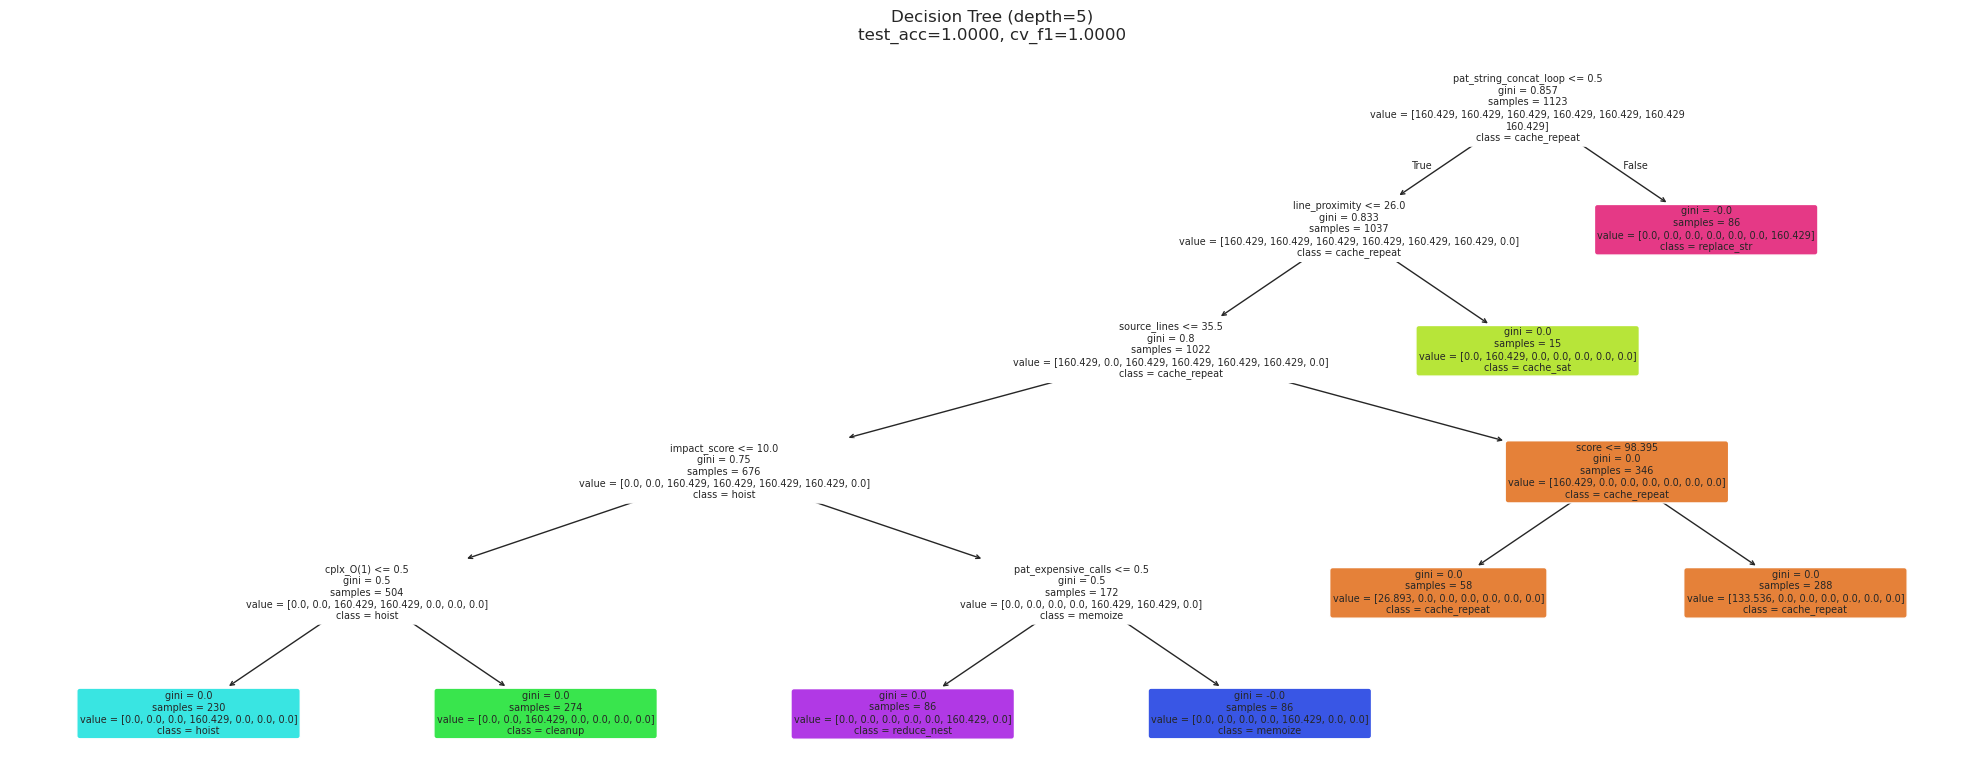

In [19]:
# plot 1: decision tree

dt_model = results["Decision Tree"]["model"]

plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=ALL_FEATURES,
    class_names=short_labels,
    filled=True,
    rounded=True,
    fontsize=7
)

plt.title(
    f"Decision Tree (depth=5)\n"
    f"test_acc={results['Decision Tree']['test_acc']:.4f}, "
    f"cv_f1={results['Decision Tree']['cv_f1_mean']:.4f}"
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "clf_decision_tree.png"), dpi=130)
plt.show()
plt.close()

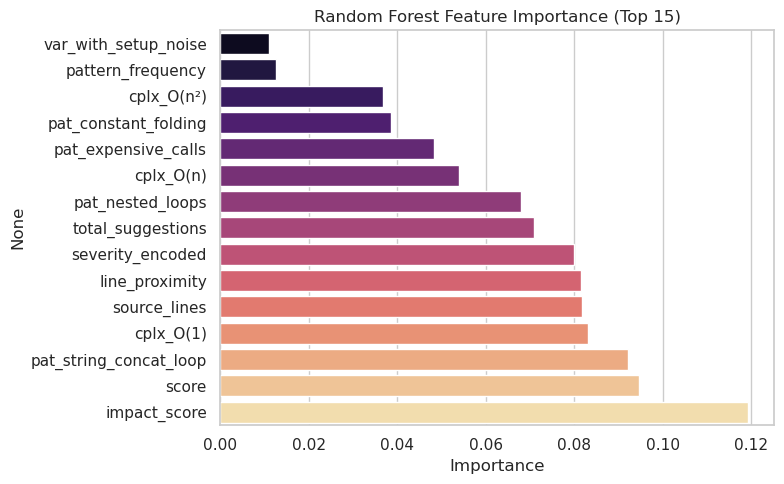

In [20]:
# plot 2: feature importance

rf_model = results["Random Forest"]["model"]

importances = (
    pd.Series(rf_model.feature_importances_, index=ALL_FEATURES)
    .sort_values()
    .tail(15)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='magma')

plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "clf_feature_importance.png"), dpi=150)
plt.show()
plt.close()

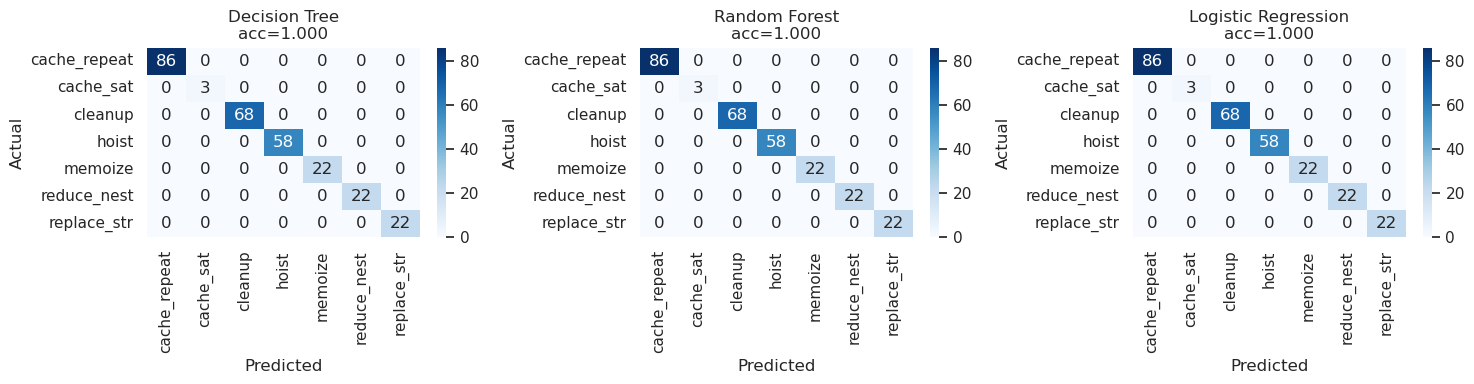

In [21]:
# plot 3: confusion matrices

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=short_labels,
        yticklabels=short_labels,
        ax=ax
    )
    ax.set_title(f"{name}\nacc={res['test_acc']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "clf_confusion_matrices.png"), dpi=150)
plt.show()
plt.close()

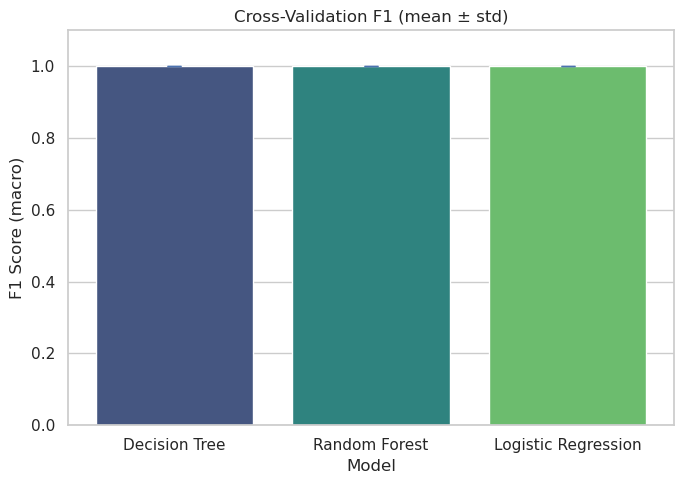

In [22]:
# plot 4: CV comparison

model_names = list(results.keys())

cv_df = pd.DataFrame({
    "Model": model_names,
    "F1 Mean": [results[m]["cv_f1_mean"] for m in model_names],
    "F1 Std": [results[m]["cv_f1_std"] for m in model_names]
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=cv_df,
    x="Model",
    y="F1 Mean",
    errorbar=None,
    palette="viridis"
)

plt.errorbar(
    x=np.arange(len(cv_df)),
    y=cv_df["F1 Mean"],
    yerr=cv_df["F1 Std"],
    fmt="none",
    capsize=5
)

plt.ylim(0, 1.1)
plt.ylabel("F1 Score (macro)")
plt.title("Cross-Validation F1 (mean ± std)")

plt.tight_layout()
p = os.path.join(PLOTS_DIR, "clf_cv_comparison.png")
plt.savefig(p, dpi=150)
plt.show()
plt.close()

In [23]:
# plot 5: tree text

dt_text_d3 = export_text(dt_model, feature_names=ALL_FEATURES, max_depth=3)
dt_text_full = export_text(dt_model, feature_names=ALL_FEATURES)

with open(os.path.join(PLOTS_DIR, "clf_decision_tree_text.txt"), "w") as f:
    f.write("=== Depth=3 Preview ===\n\n")
    f.write(dt_text_d3)
    f.write("\n\n=== Full Tree ===\n\n")
    f.write(dt_text_full)